# Прогнозирование волатильности BTC-USDT

В ноутбуке собран полный воспроизводимый пайплайн проекта:
- загрузка часовых данных KuCoin;
- подготовка признаков;
- baseline-модель GARCH(1,1);
- DL-модель LSTM;
- walk-forward валидация без утечки данных;
- применение прогноза волатильности в vol-targeting стратегии;
- расчёт Sharpe, Max Drawdown и Monte Carlo сценариев.

## 1. Импорт библиотек и подготовка путей
Сначала подключим код проекта и посмотрим, где лежат артефакты полного прогона.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

CONFIG_PATH = ROOT / 'config' / 'btc_kucoin_hourly.json'
SUMMARY_PATH = ROOT / 'reports' / 'summary.json'
PRED_PATH = ROOT / 'reports' / 'predictions.csv'
FORECAST_METRICS_PATH = ROOT / 'reports' / 'forecast_metrics.csv'
STRATEGY_METRICS_PATH = ROOT / 'reports' / 'strategy_metrics.csv'
FEATURE_PATH = ROOT / 'data' / 'processed' / 'feature_frame.csv'
FORECAST_PLOT = ROOT / 'reports' / 'forecast_comparison.png'
EQUITY_PLOT = ROOT / 'reports' / 'equity_curve.png'
MONTE_CARLO_PLOT = ROOT / 'reports' / 'monte_carlo_volatility.png'


## 2. Полный прогон проекта
Следующая ячейка запускает полный pipeline. Если артефакты уже построены, можно её не выполнять повторно.

In [2]:
from ml_for_stock_market.pipeline import run_pipeline

# summary = run_pipeline(str(CONFIG_PATH))
# print(json.dumps(summary, indent=2, ensure_ascii=False))

## 3. Загрузка готовых результатов
Подгрузим summary, метрики и подготовленный датасет.

In [3]:
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
predictions = pd.read_csv(PRED_PATH, parse_dates=['timestamp'])
forecast_metrics = pd.read_csv(FORECAST_METRICS_PATH)
strategy_metrics = pd.read_csv(STRATEGY_METRICS_PATH)
feature_frame = pd.read_csv(FEATURE_PATH, parse_dates=['timestamp'])

summary

{'symbol': 'BTC-USDT',
 'rows_raw': 62732,
 'rows_features': 62563,
 'walk_forward_points': 51797,
 'best_forecast_model': 'lstm',
 'latest_forecast_annual_vol': 0.2868877947330475,
 'forecast_metrics': [{'model': 'garch',
   'mae': 0.2642385713940344,
   'rmse': 0.3350785849008944,
   'mape_pct': 78.20967819076925,
   'correlation': 0.37826203268510605},
  {'model': 'lstm',
   'mae': 0.15925845777916817,
   'rmse': 0.24412634206606554,
   'mape_pct': 33.414129890590196,
   'correlation': 0.4949746555688587}],
 'strategy_metrics': [{'model': 'buy_hold',
   'total_return_pct': 959.3025735816673,
   'cagr_pct': 49.05728103692007,
   'sharpe': 0.9495784053303846,
   'max_drawdown_pct': -77.19171932933826,
   'avg_exposure': 1.0,
   'turnover': 0.0},
  {'model': 'garch',
   'total_return_pct': 215.93079701065344,
   'cagr_pct': 21.476389100214497,
   'sharpe': 0.8036420897132888,
   'max_drawdown_pct': -56.21993332741104,
   'avg_exposure': 0.547255956784928,
   'turnover': 538.04904635905

## 4. Проверка данных
Посмотрим на объём выборки и на первые строки подготовленного признакового датасета.

In [4]:
print('Rows in feature frame:', len(feature_frame))
print('Date range:', feature_frame['timestamp'].min(), '->', feature_frame['timestamp'].max())
display(feature_frame.head())

Rows in feature frame: 62563
Date range: 2019-01-08 00:00:00+00:00 -> 2026-02-28 22:00:00+00:00


,timestamp,open,high,low,close,volume,turnover,log_return,forward_return_1h,abs_return,...,momentum_6h,momentum_24h,ema_gap_12_48,vol_ratio_6_24,vol_ratio_24_168,hour_sin,hour_cos,dow_sin,dow_cos,target_vol
0,2019-01-08 00:00:00+00:00,3977.721738,3988.000000,3973.511648,3983.020593,0.316212,1258.150866,0.002704,-0.005410,0.002704,...,0.001688,-0.007502,0.011716,0.779999,0.643462,0.000000,1.000000,0.781831,0.62349,0.308521
1,2019-01-08 01:00:00+00:00,3974.422438,3974.422438,3956.091484,3961.472677,1.880674,7463.370129,-0.005425,-0.002432,0.005425,...,-0.005668,-0.007335,0.010842,0.965763,0.640398,0.258819,0.965926,0.781831,0.62349,0.323419
2,2019-01-08 02:00:00+00:00,3961.472690,3968.793914,3925.000000,3951.837959,4.198858,16544.008598,-0.002435,-0.001551,0.002435,...,-0.003645,-0.007857,0.009789,0.871496,0.642007,0.500000,0.866025,0.781831,0.62349,0.320863
3,2019-01-08 03:00:00+00:00,3945.000002,3956.365220,3942.092269,3945.708317,0.964437,3810.502221,-0.001552,-0.000754,0.001552,...,-0.007369,-0.011303,0.008697,0.790698,0.637407,0.707107,0.707107,0.781831,0.62349,0.320078
4,2019-01-08 04:00:00+00:00,3945.708317,3947.732199,3937.500515,3942.732197,1.634630,6442.919238,-0.000755,0.001256,0.000755,...,-0.006388,-0.010783,0.007670,0.789561,0.636745,0.866025,0.500000,0.781831,0.62349,0.326267


## 5. Качество прогноза волатильности
Сравним baseline GARCH и LSTM по основным ошибкам прогнозирования.

In [5]:
display(forecast_metrics)

,model,mae,rmse,mape_pct,correlation
0,garch,0.264239,0.335079,78.209678,0.378262
1,lstm,0.159258,0.244126,33.414130,0.494975


## 6. Метрики применения модели
Ниже показаны метрики для стратегии с управлением риском через прогноз волатильности.

In [6]:
display(strategy_metrics)

,model,total_return_pct,cagr_pct,sharpe,max_drawdown_pct,avg_exposure,turnover
0,buy_hold,959.302574,49.057281,0.949578,-77.191719,1.000000,0.000000
1,garch,215.930797,21.476389,0.803642,-56.219933,0.547256,538.049046
2,lstm,295.109775,26.158920,0.872595,-56.847319,0.580660,196.839737


## 7. Графики
Покажем график фактической и прогнозной волатильности, а также кривую капитала стратегии.

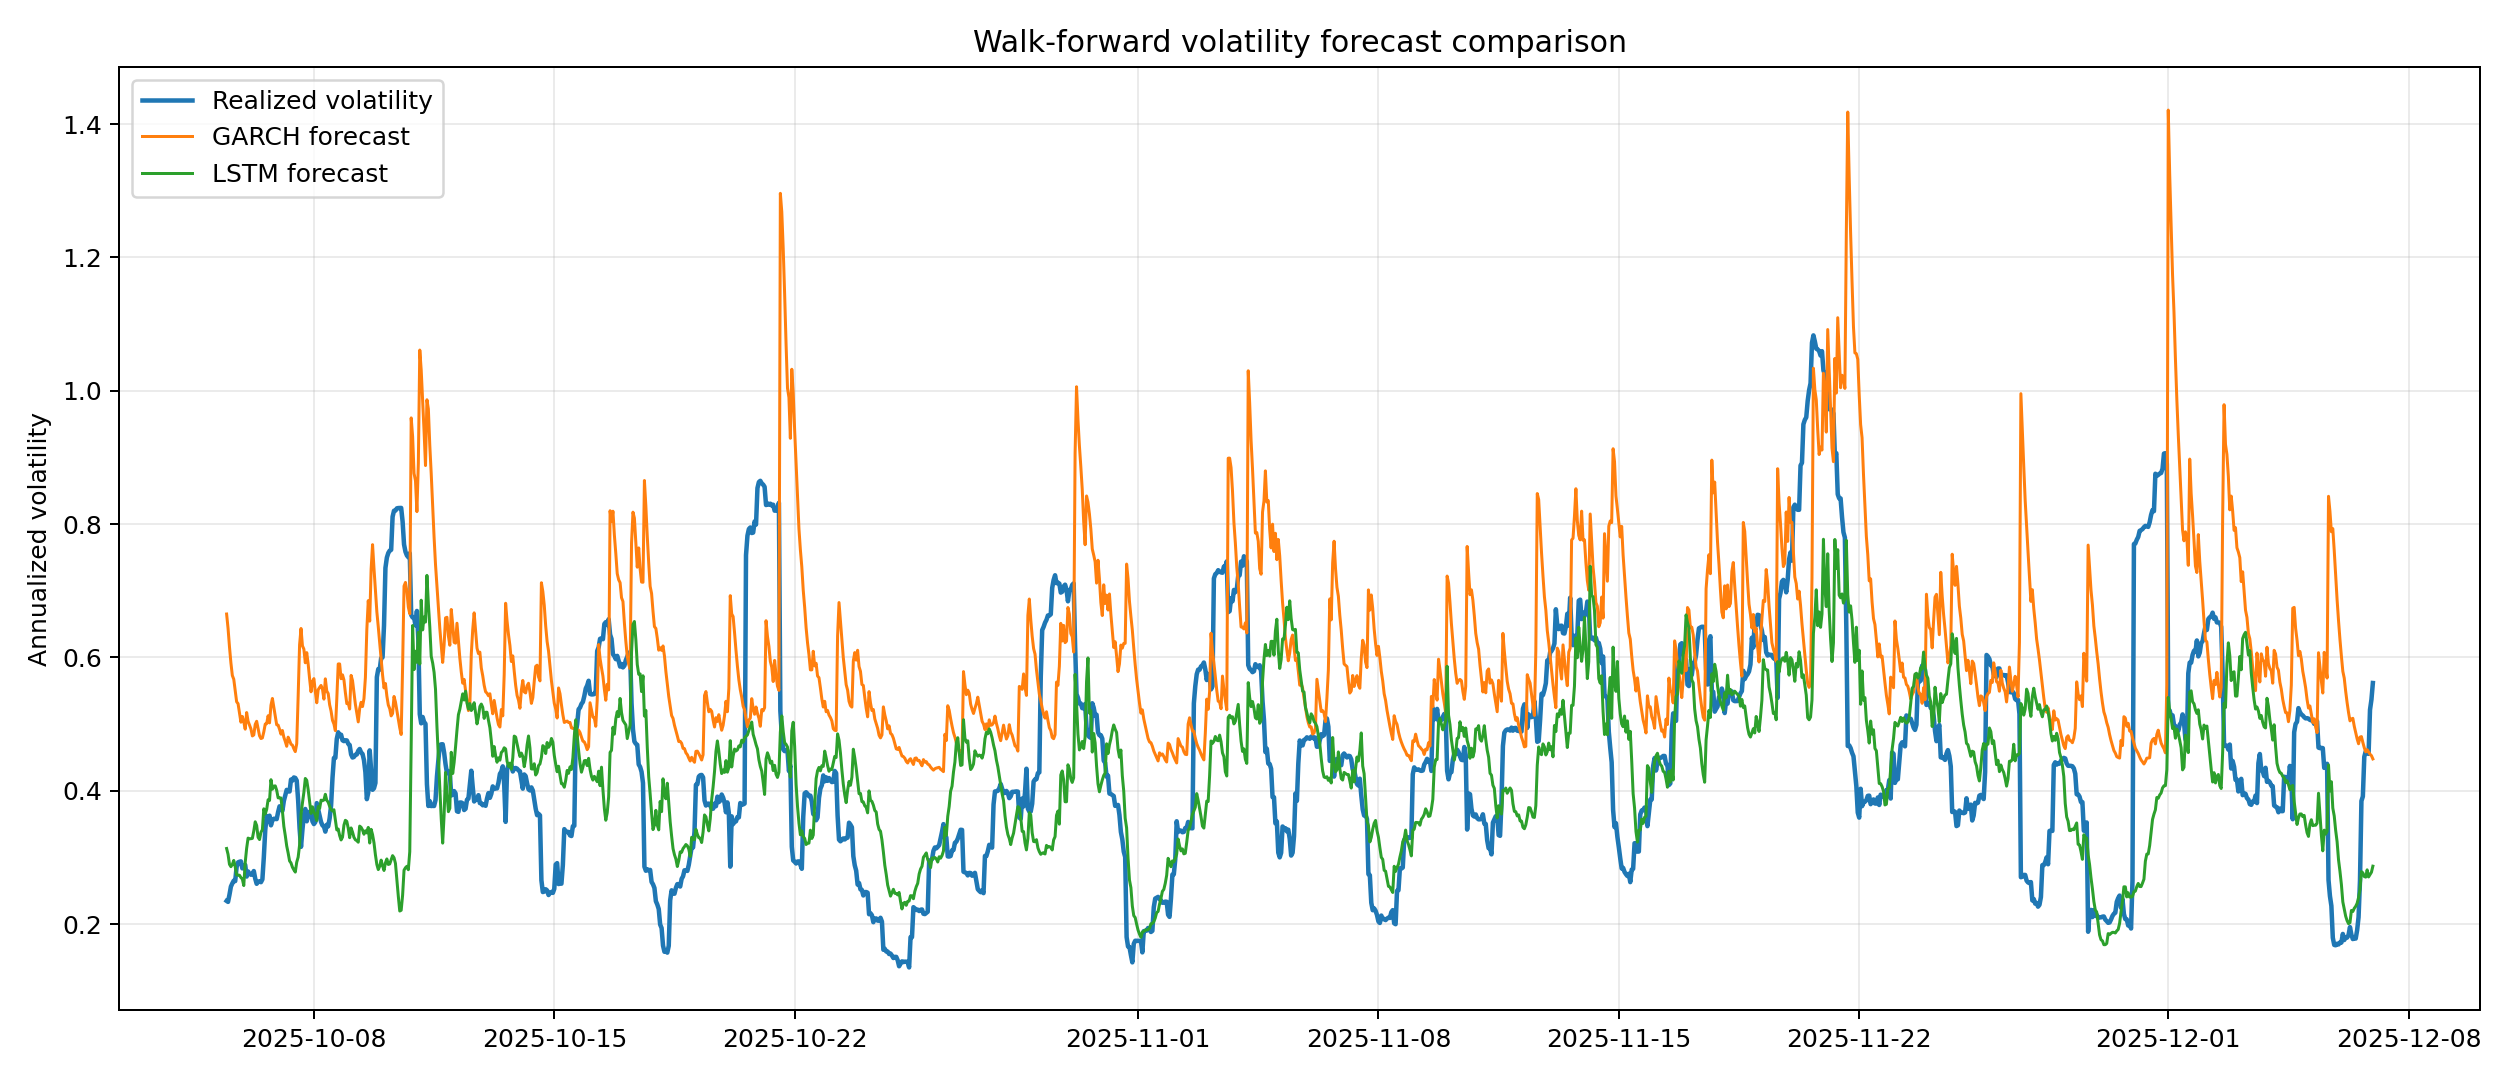

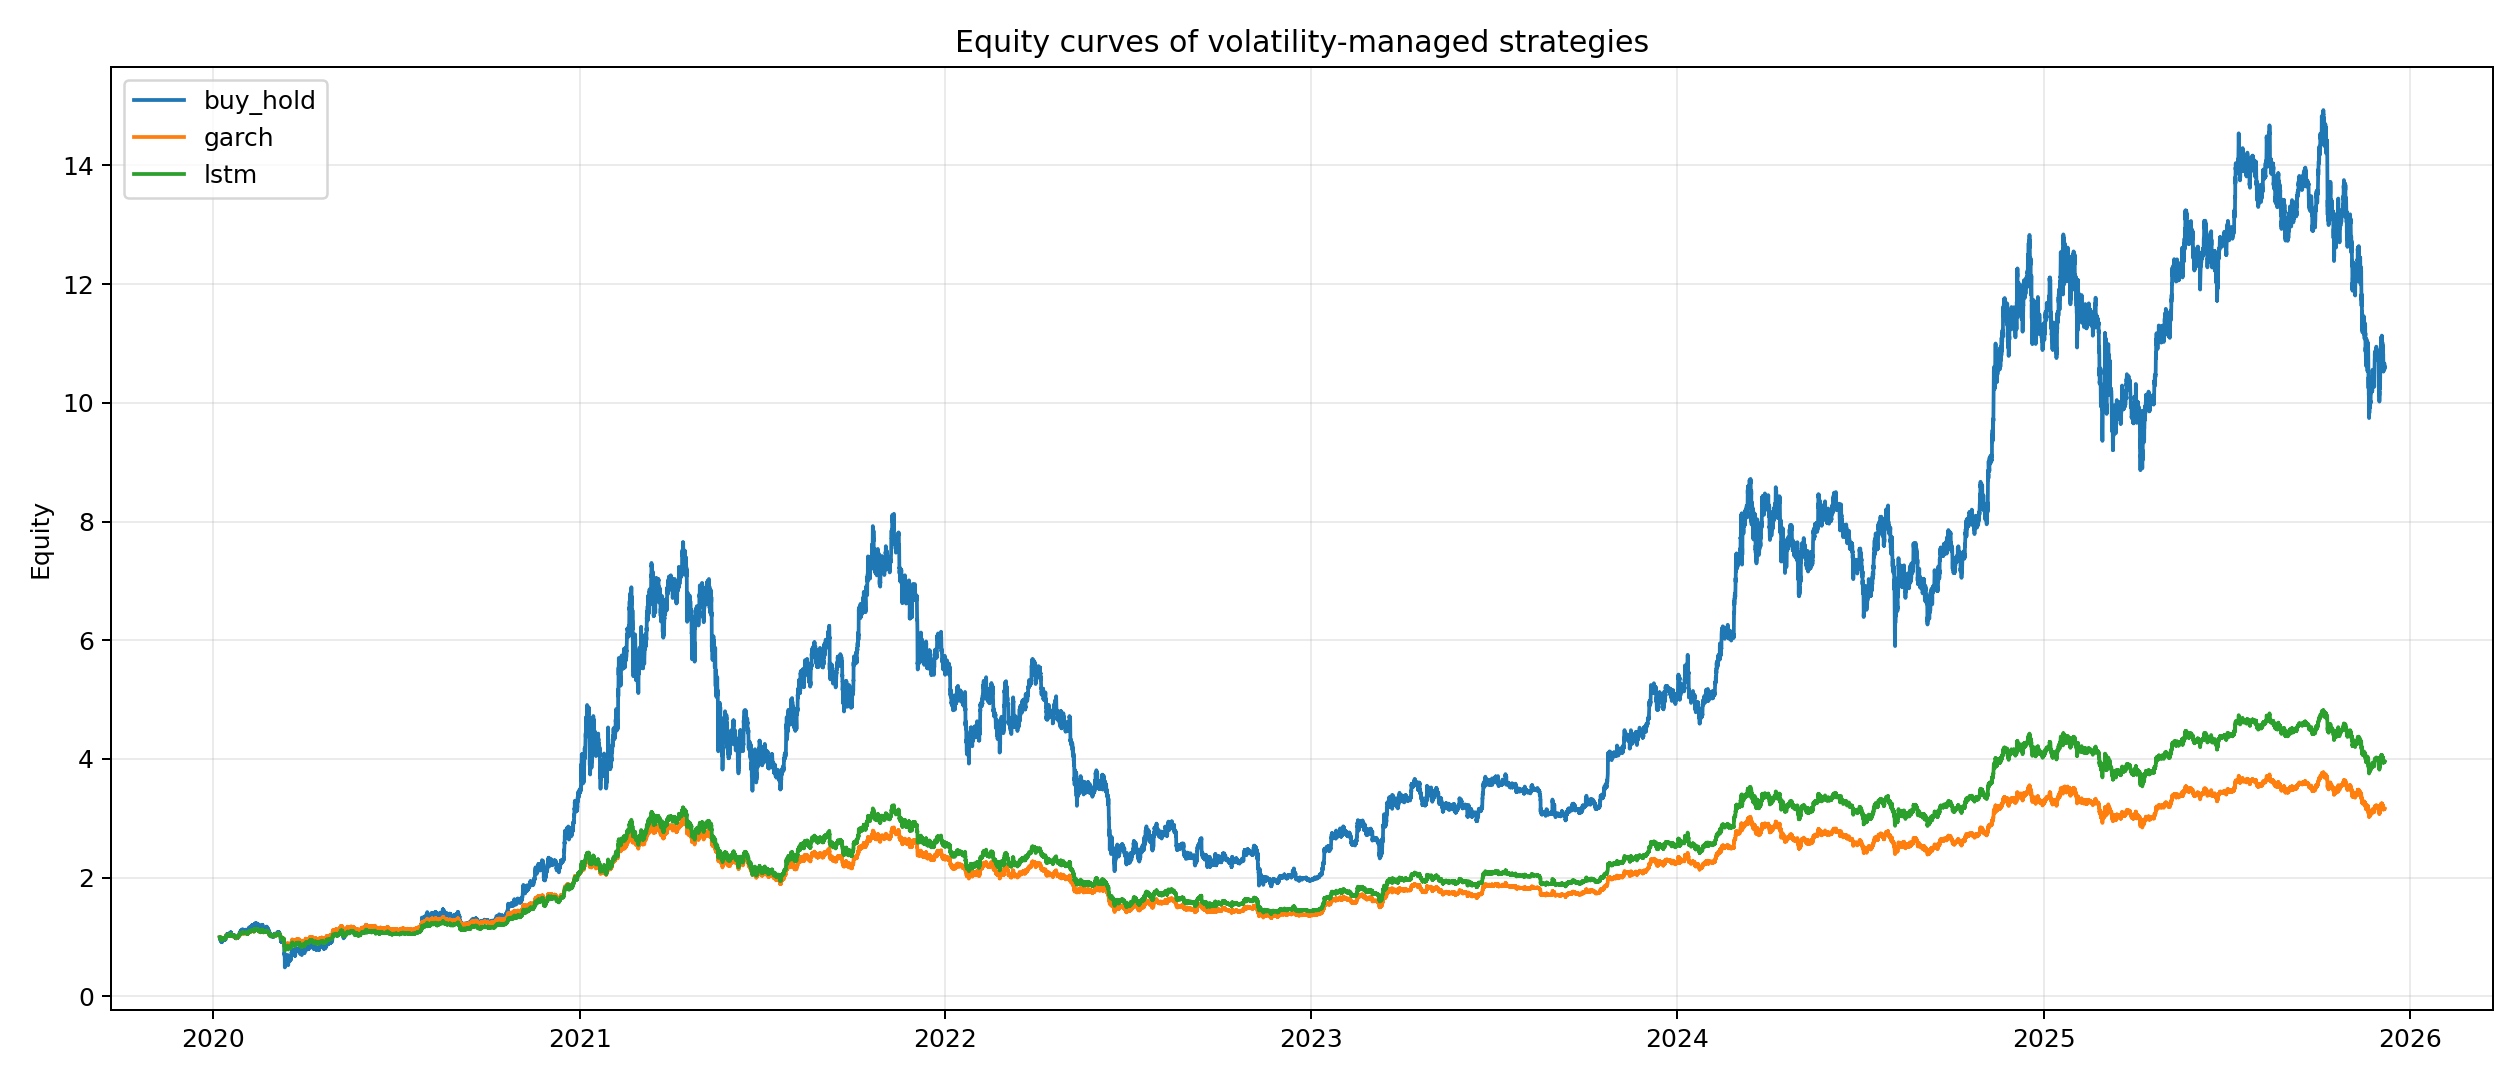

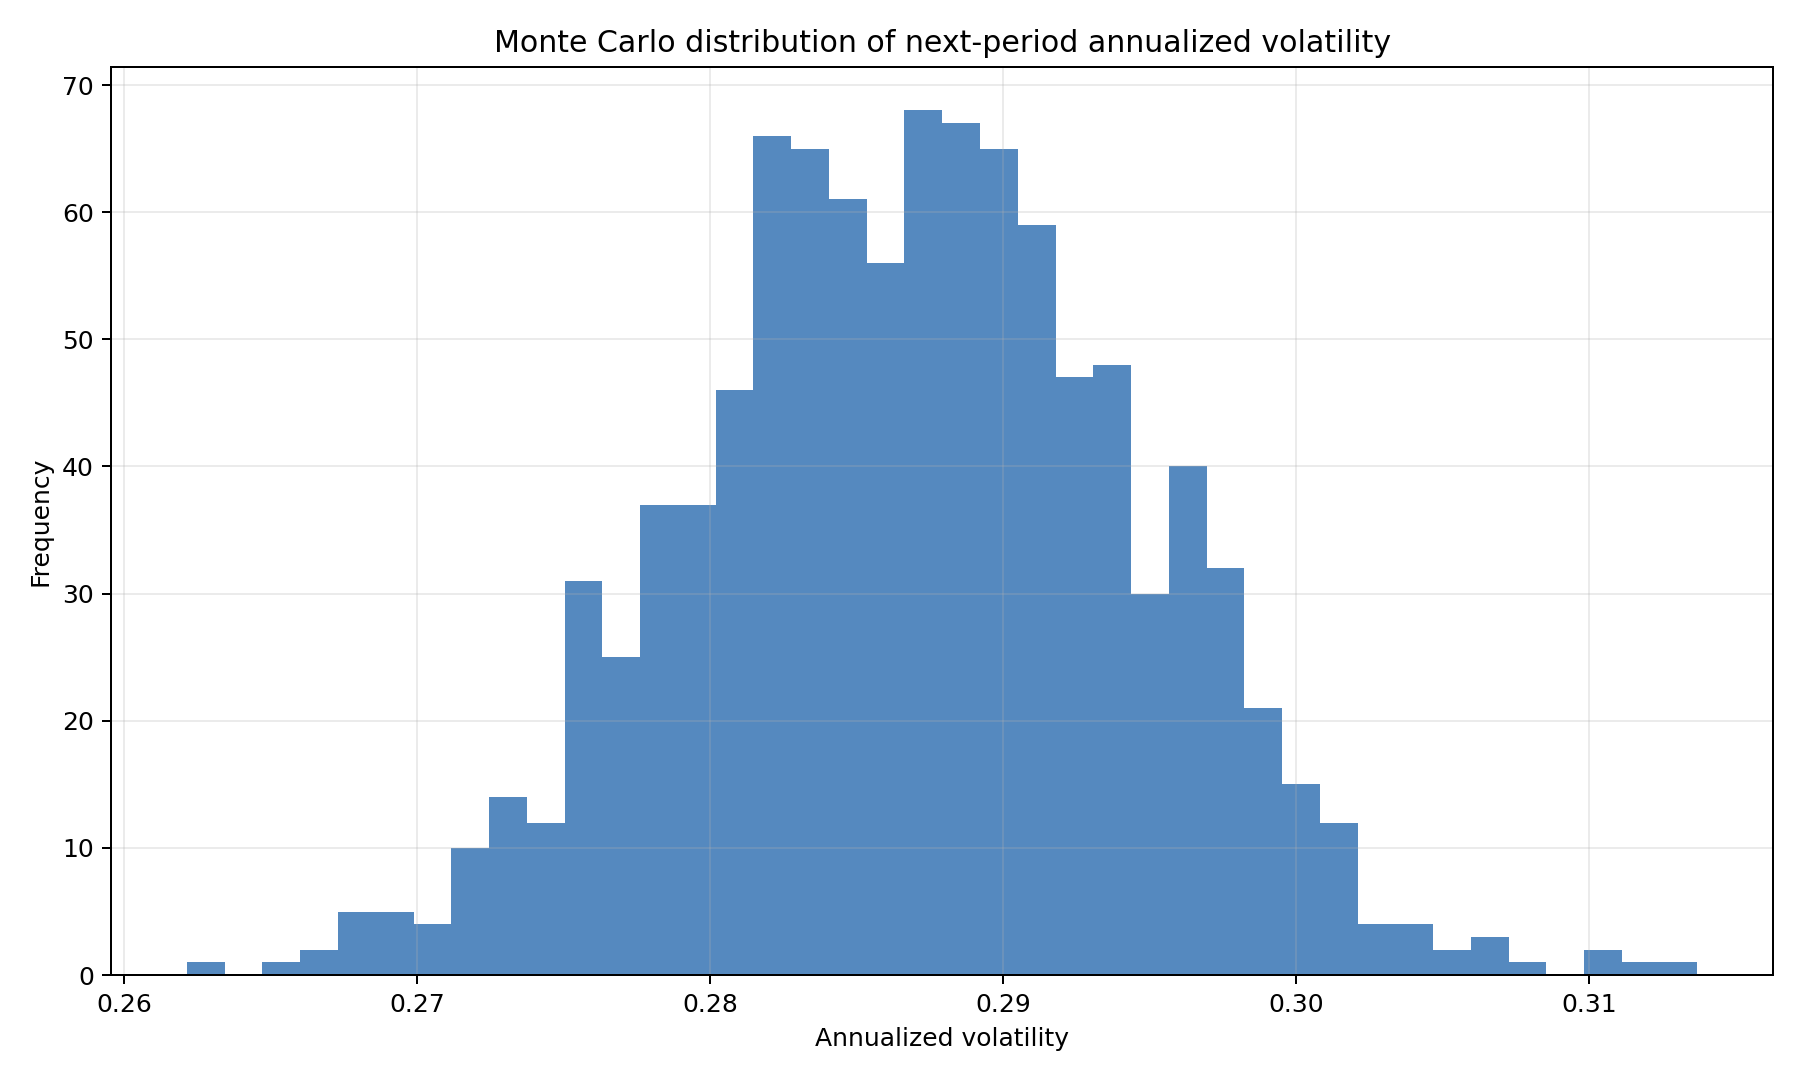

In [7]:
display(Image(filename=str(FORECAST_PLOT)))
display(Image(filename=str(EQUITY_PLOT)))
display(Image(filename=str(MONTE_CARLO_PLOT)))

## 8. Краткие выводы
1. LSTM лучше baseline GARCH по RMSE, MAE и корреляции с реализованной волатильностью.
2. В прикладной части прогноз волатильности использовался для vol-targeting, а не для предсказания направления цены.
3. Monte Carlo даёт диапазон возможной будущей волатильности и помогает в сценарном риск-анализе.